In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
%matplotlib inline

sns.set_style("white")
sns.set_style("ticks")
sns.set_context("notebook", font_scale=1.3)

!wget https://github.com/googlefonts/atkinson-hyperlegible/raw/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf
matplotlib.font_manager.fontManager.addfont('AtkinsonHyperlegible-Regular.ttf')
plt.rcParams.update({"font.family": "Atkinson Hyperlegible"})

--2025-10-20 12:29:35--  https://github.com/googlefonts/atkinson-hyperlegible/raw/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/googlefonts/atkinson-hyperlegible/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf [following]
--2025-10-20 12:29:35--  https://raw.githubusercontent.com/googlefonts/atkinson-hyperlegible/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54348 (53K) [application/octet-stream]
Saving to: ‘AtkinsonHyperlegible-Regular.ttf.1’

AtkinsonHyperlegibl 

In [131]:
METRIC_NAME = "pcw"

In [132]:
# Read the CSV file
df = pd.read_csv(f'{METRIC_NAME}_results.csv')

In [133]:
# Languages (columns) to plot
languages = {
    "eng_Latn": "English",
    "zho_Hans": "Chinese",
    "tur_Latn": "Turkish",
    "pes_Arab": "Persian",
    "ita_Latn": "Italian"
}

if METRIC_NAME == "parity":
  languages = {
    "zho_Hans": "Chinese",
    "tur_Latn": "Turkish",
    "pes_Arab": "Persian",
    "ita_Latn": "Italian"
}


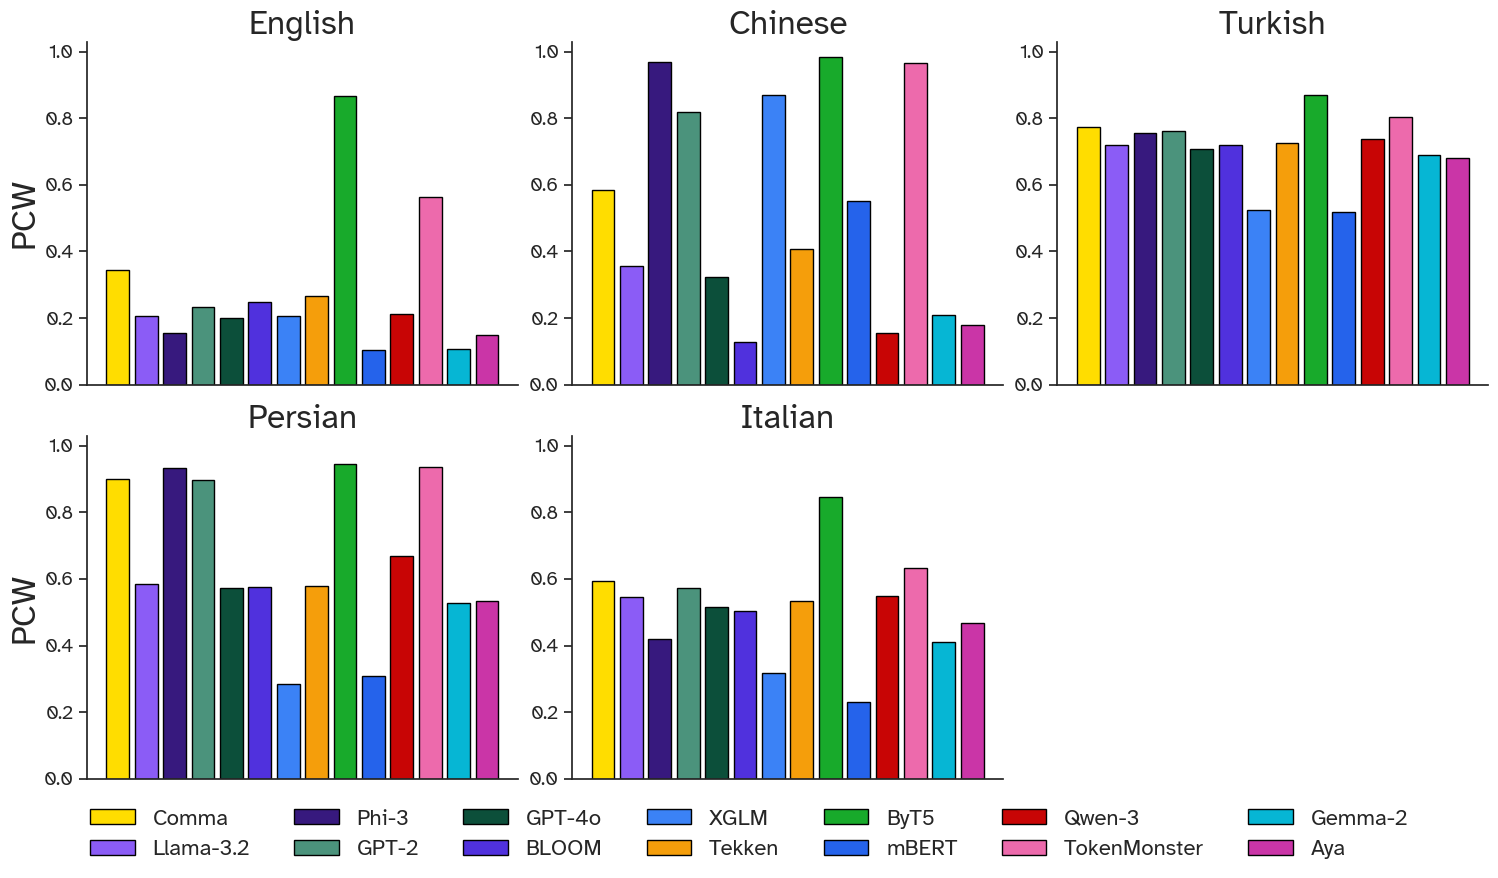

In [134]:
# Get model names
models = df['model_name'].tolist()
num_models = len(models)

# Define base colors for each model family
MODEL_FAMILY_COLORS = {
    "mpt": "#78909C",  # Brighter blue-grey
    "llama": "#5B21FF",  # Brighter purple
    "qwen": "#FF3E30",  # Brighter red
    "gpt": "#4285F4",  # Google Blue
    "xglm": "#0081FB",  # Meta Blue
    "mistral": "#00C853",  # Brighter green
    "gemma": "#FFD600",  # Brighter yellow
    "claude": "#FF9100",  # Brighter orange
    "phi": "#00E5FF",  # Brighter cyan
    "aya": "#8D6E63",  # Brighter brown
    "pythia": "#FF6E40",  # Brighter deep orange
    "comma": "#FFDD00",  # orange
    "llama": "#8B5CF6",  # Violet
    "qwen": "#C80505",  # Red
    "gpt-4o": "#0C4F3A",  # Emerald
    "gpt2": "#4B937CFF",  # Emerald
    "xglm": "#3B82F6",  # Blue
    "mistral": "#F59E0B",  # Amber
    "gemma": "#06B6D4",  # Cyan
    "claude": "#F97316",  # Orange
    "phi": "#37197E",  # Purple
    "aya": "#CA35A7",  # Pink
    "pythia": "#7476EC",  # Indigo
    "byt5": "#18AA2B",  # Emerald-600
    "mbert": "#2563EB",  # Blue-600
    "bloom": "#5031DD",  # Violet-600
    "tokenmonster": "#ED6AAC",
}

color_map = {
    "Comma": MODEL_FAMILY_COLORS["comma"],
    "Llama-3.2": MODEL_FAMILY_COLORS["llama"],
    "Phi-3": MODEL_FAMILY_COLORS["phi"],
    "GPT-2": MODEL_FAMILY_COLORS["gpt2"],
    "GPT-4o": MODEL_FAMILY_COLORS["gpt-4o"],
    "BLOOM": MODEL_FAMILY_COLORS["bloom"],
    "XGLM": MODEL_FAMILY_COLORS["xglm"],
    "Tekken": MODEL_FAMILY_COLORS["mistral"],
    "ByT5": MODEL_FAMILY_COLORS["byt5"],
    "mBERT": MODEL_FAMILY_COLORS["mbert"],
    "Qwen-3": MODEL_FAMILY_COLORS["qwen"],
    "TokenMonster": MODEL_FAMILY_COLORS["tokenmonster"],
    "Gemma-2": MODEL_FAMILY_COLORS["gemma"],
    "Aya": MODEL_FAMILY_COLORS["aya"],
}

# Get colors for each model, use default color if model not in map
colors = [color_map.get(model, '#999999') for model in models]

def clean_up(ax):
    sns.despine()
    ax.tick_params(direction="out", which="both")
    ax.set_xticks([])

# Create subplots - 2 rows, 3 columns (3 on top, 2 on bottom)
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

# Find global min and max across all languages for consistent y-axis
all_values = []
for lang_code in languages.keys():
    all_values.extend(df[lang_code].tolist())
global_min = min(all_values)
global_max = max(all_values)

for idx, (lang_code, lang_name) in enumerate(languages.items()):
    ax = axs[idx]

    # Get values for this language
    values = df[lang_code].tolist()

    # Create bar positions
    x_pos = np.arange(num_models)

    # Create bars
    bars = ax.bar(x_pos, values, edgecolor="k", linewidth=1, color=colors)

    # Set title and labels
    ax.set_title(lang_name, fontsize=24)
    if METRIC_NAME == "fertility":
      ax.set_ylabel("Fertility" if idx % 3 == 0 else "", fontsize=24)
    elif METRIC_NAME == "parity":
      ax.set_ylabel("Parity" if idx % 3 == 0 else "", fontsize=24)
    elif METRIC_NAME == "pcw":
      ax.set_ylabel("PCW" if idx % 3 == 0 else "", fontsize=24)
    else:
      ax.set_ylabel(METRIC_NAME if idx % 3 == 0 else "", fontsize=20)

    # Use consistent y-axis limits across all subplots
    score_range = global_max - global_min
    ax.set_ylim(0, global_max + 0.05*score_range)

    clean_up(ax)

# Hide the last subplot (since we only have 5 languages)
axs[5].set_visible(False)

if METRIC_NAME == "parity":
  axs[4].set_visible(False)


fig.tight_layout(pad=0.5)


# Create legend with model names
fig.legend(bars, models, ncols=min(7, num_models), frameon=False,
          loc="lower center", bbox_to_anchor=(0.5, -0.1), fontsize=16)

plt.savefig(f"{METRIC_NAME}.png", pad_inches=0, bbox_inches="tight")
plt.show()